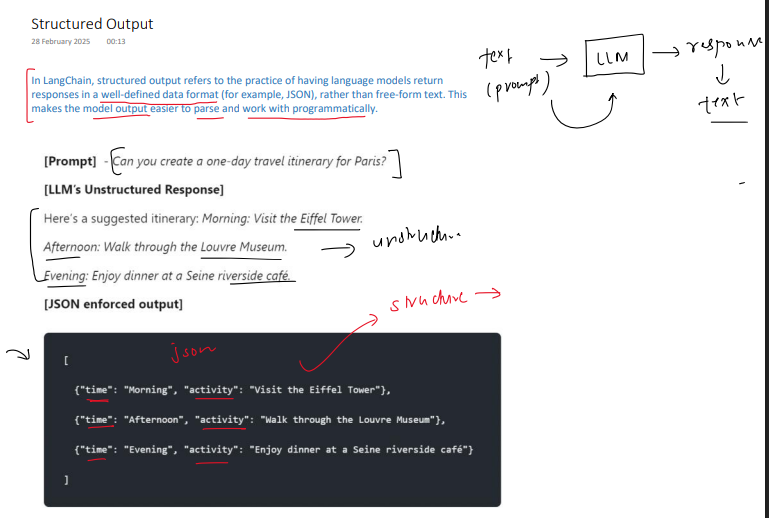

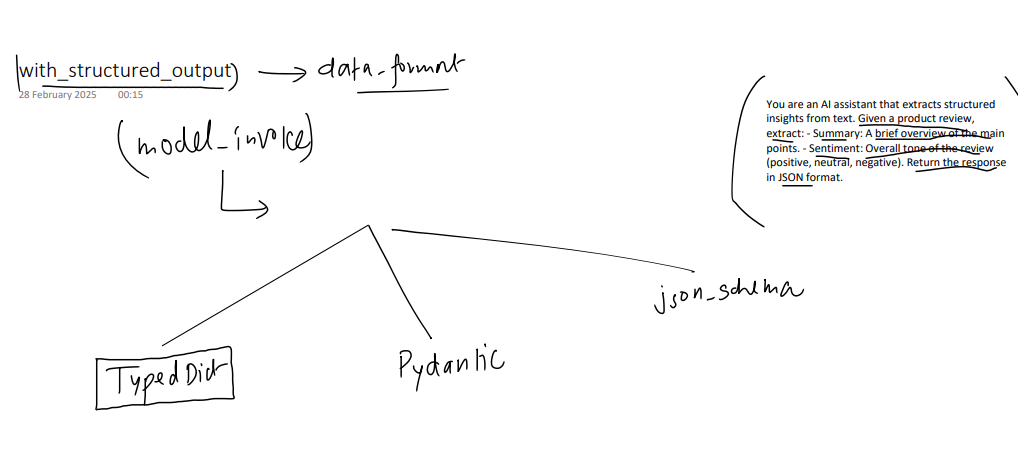

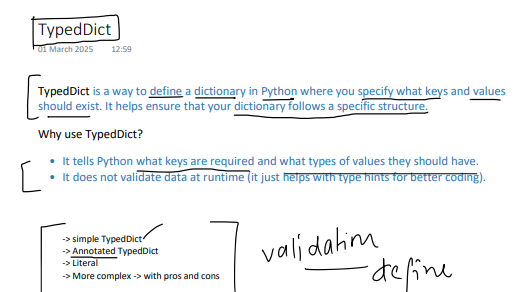

### structured output => Typedict

In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal

load_dotenv()

model = ChatGroq(model = "openai/gpt-oss-120b")

# schema
class Review(TypedDict):

    key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    summary: Annotated[str, "A brief summary of the review"]
    sentiment: Annotated[Literal["pos", "neg"], "Return sentiment of the review either negative, positive or neutral"]
    pros: Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    cons: Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    name: Annotated[Optional[str], "Write the name of the reviewer"]
    

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by vi
""")
print(result)
print(result['sentiment'])
print(result['name'])

{'cons': ['Heavy and large, uncomfortable for one-handed use', 'Samsung One UI includes bloatware with redundant apps', 'High price tag of $1,300'], 'key_themes': ['Performance', 'Camera quality', 'Battery life', 'S-Pen integration', 'Ergonomics', 'Software bloatware', 'Pricing'], 'name': 'vi', 'pros': ['Insanily powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful'], 'sentiment': 'pos', 'summary': 'The Samsung Galaxy S24 Ultra delivers top-tier performance, an impressive 200MP camera, and solid battery life, but its size, bloatware, and high price are notable drawbacks.'}
pos
vi


### Pydantic

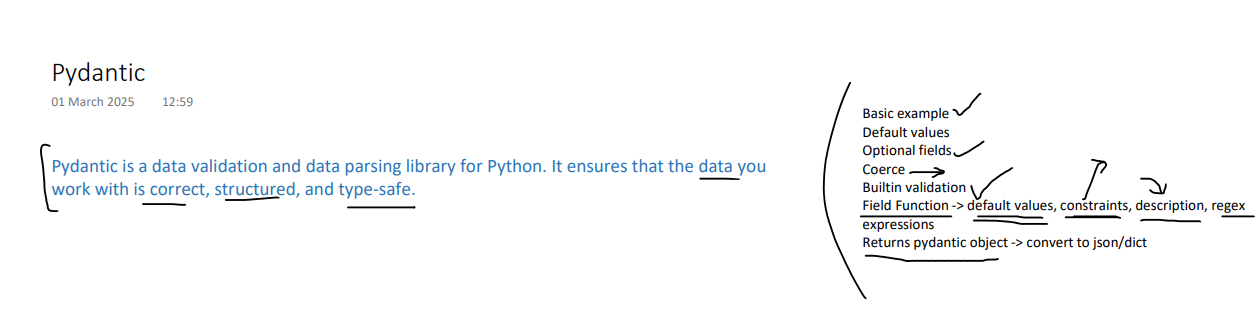

In [ ]:
from pydantic import BaseModel, EmailStr, Field
from typing import Optional

class Student(BaseModel):

    name: str = 'nitish'
    age: Optional[int] = None
    email: EmailStr
    cgpa: float = Field(gt=0, lt=10, default=5, description='A decimal value representing the cgpa of the student')


new_student = {'age':'32', 'email':'abc@gmail.com'}

student = Student(**new_student)

student_dict = dict(student)

print(student_dict['age'])

student_json = student.model_dump_json()# conversion to json
print(student_json)

32
{"name":"nitish","age":32,"email":"abc@gmail.com","cgpa":5.0}


In [5]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field

load_dotenv()

model = ChatGroq(model ="openai/gpt-oss-120b")

# schema
class Review(BaseModel):

    key_themes: list[str] = Field(description="Write down all the key themes discussed in the review in a list")
    summary: str = Field(description="A brief summary of the review")
    sentiment: Literal["pos", "neg"] = Field(description="Return sentiment of the review either negative, positive or neutral")
    pros: Optional[list[str]] = Field(default=None, description="Write down all the pros inside a list")
    cons: Optional[list[str]] = Field(default=None, description="Write down all the cons inside a list")
    name: Optional[str] = Field(default=None, description="Write the name of the reviewer")
    

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result)

key_themes=['Performance', 'Camera quality', 'Battery life', 'S-Pen integration', 'Ergonomics', 'Software bloatware', 'Price'] summary='The Samsung Galaxy S24 Ultra delivers top-tier performance, an impressive 200MP camera, and solid battery life with fast charging, though its bulk, software bloat, and steep price are notable drawbacks.' sentiment='pos' pros=['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful'] cons=['Large size and heavy weight make one-handed use uncomfortable', 'One UI includes bloatware and redundant apps', 'High price of $1,300'] name='Nitish Singh'


#### JSON

In [7]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field

load_dotenv()

model = ChatGroq(model="openai/gpt-oss-120b")

# schema
json_schema = {
  "title": "Review",
  "type": "object",
  "properties": {
    "key_themes": {
      "type": "array",
      "items": {
        "type": "string"
      },
      "description": "Write down all the key themes discussed in the review in a list"
    },
    "summary": {
      "type": "string",
      "description": "A brief summary of the review"
    },
    "sentiment": {
      "type": "string",
      "enum": ["pos", "neg"],
      "description": "Return sentiment of the review either negative, positive or neutral"
    },
    "pros": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the pros inside a list"
    },
    "cons": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the cons inside a list"
    },
    "name": {
      "type": ["string", "null"],
      "description": "Write the name of the reviewer"
    }
  },
  "required": ["key_themes", "summary", "sentiment"]
}


structured_model = model.with_structured_output(json_schema)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result)

{'cons': ['Heavy and large size makes one‑handed use uncomfortable', "Samsung's One UI includes a lot of bloatware", 'High $1,300 price tag', 'Zoom quality degrades beyond 30x'], 'key_themes': ['Performance', 'Battery life', 'Camera quality', 'S‑Pen integration', 'Ergonomics/design', 'Software bloat', 'Pricing'], 'name': 'Nitish Singh', 'pros': ['Insanely powerful Snapdragon 8 Gen 3 processor for gaming and productivity', 'Stunning 200MP camera with excellent night mode and effective zoom up to 100x', 'Long-lasting 5000mAh battery with 45W fast charging', 'S‑Pen support for note‑taking and sketches'], 'sentiment': 'pos', 'summary': 'The Samsung Galaxy S24 Ultra impresses with a top‑tier processor, massive 200MP camera, solid battery life, and S‑Pen support, but its bulky size, preinstalled bloatware, and steep price are notable drawbacks.'}


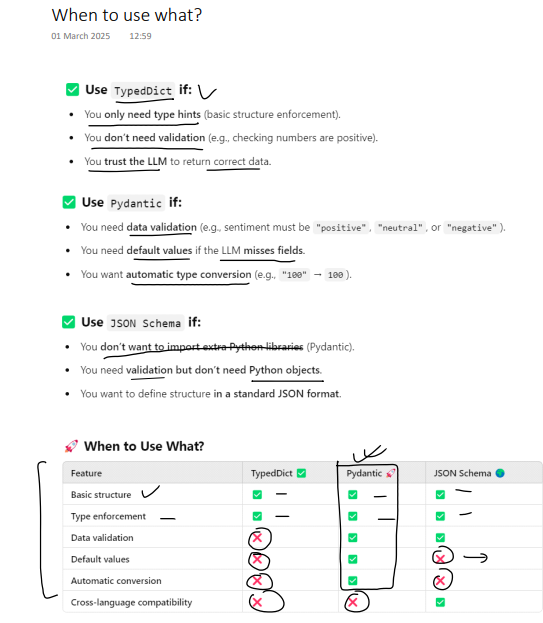